# Probing Decision Boundaries

This notebook probes the decision boundary geometry and local disagreement.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [1]:
%pip install numpy pandas matplotlib scikit-learn torch -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Synthetic Dataset Generation and Standardization

In this section, we define the data generating functions to produce synthetic 2D datasets—specifically `moons`, `circles`, and a noisy XOR (`make_xor`). The XOR dataset introduces explicit corner regions where decision boundaries are non-trivial. The continuous nature of these datasets allows us to systematically probe arbitrary regions of the input space to evaluate the geometry of teacher-surrogate disagreement.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print("Using device:", DEVICE)


Using device: mps


In [4]:
def make_xor(n_samples=1500, noise=0.25, random_state=42):
    rng = np.random.default_rng(random_state)
    X = rng.normal(size=(n_samples, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(int)
    X += rng.normal(scale=noise, size=X.shape)
    return X, y


def load_dataset(name, n_samples=1500, noise=0.25, random_state=42):
    if name == "moons":
        return make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    if name == "circles":
        return make_circles(n_samples=n_samples, noise=noise, factor=0.45, random_state=random_state)
    if name == "xor":
        return make_xor(n_samples=n_samples, noise=noise, random_state=random_state)
    raise ValueError(f"Unknown dataset: {name}")


### Teacher Model Definition and Optimization

This section defines the neural network architecture (`TeacherMLP`), a two-layer multi-layer perceptron with ReLU activations used as our complex, opaque teacher model. We also provide the optimization loop (`train_teacher`) which fits this model via Adam and BCEWithLogitsLoss. Note that the actual training of the teacher and its corresponding transparent surrogate (a Logistic Regression model) is encapsulated in the subsequent experimental pipeline.

In [5]:
class TeacherMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, epochs=500, batch_size=64, lr=1e-3, verbose=False):
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)

        if verbose and (epoch + 1) % 100 == 0:
            print(f"epoch={epoch + 1}, loss={total_loss / len(X_train):.4f}")

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs


### Local Boundary Fidelity and Experimental Pipeline

We construct a 2D mesh grid (`make_grid`) to visualize the spatial structure of teacher-surrogate disagreements and define a rigorous metric evaluation function (`compute_metrics`). Crucially, we introduce an $\epsilon$-band around the teacher's decision boundary to measure *boundary fidelity*. The `run_experiment` function ties everything together: it generates the dataset, standardizes features, trains the MLP teacher, and then fits a linear Logistic Regression surrogate to the teacher's hard predictions, subsequently evaluating the surrogate's fidelity both globally and within the critical $\epsilon$-margin.

In [6]:
def make_grid(X, margin=0.7, grid_size=300):
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def compute_metrics(y_true, teacher_p, surrogate_p, eps=0.10):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)

    boundary_mask = np.abs(teacher_p - 0.5) <= eps
    nonboundary_mask = ~boundary_mask

    metrics = {
        "teacher_task_accuracy": accuracy_score(y_true, teacher_y),
        "surrogate_task_accuracy": accuracy_score(y_true, surrogate_y),
        "global_fidelity": accuracy_score(teacher_y, surrogate_y),
        "probability_mse": mean_squared_error(teacher_p, surrogate_p),
        "n_boundary_points": int(boundary_mask.sum()),
        "boundary_fraction": float(boundary_mask.mean()),
    }

    if boundary_mask.sum() > 0:
        metrics["boundary_fidelity"] = accuracy_score(teacher_y[boundary_mask], surrogate_y[boundary_mask])
        metrics["boundary_task_accuracy"] = accuracy_score(y_true[boundary_mask], surrogate_y[boundary_mask])
    else:
        metrics["boundary_fidelity"] = np.nan
        metrics["boundary_task_accuracy"] = np.nan

    if nonboundary_mask.sum() > 0:
        metrics["nonboundary_fidelity"] = accuracy_score(teacher_y[nonboundary_mask], surrogate_y[nonboundary_mask])
    else:
        metrics["nonboundary_fidelity"] = np.nan

    metrics["boundary_gap"] = metrics["global_fidelity"] - metrics["boundary_fidelity"]
    return metrics


In [7]:
def run_experiment(dataset_name, noise=0.25, eps=0.10, random_state=42):
    X, y = load_dataset(dataset_name, noise=noise, random_state=random_state)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=random_state, stratify=y
    )

    teacher = train_teacher(X_train, y_train, epochs=500, lr=1e-3)

    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_test_p = teacher_probs(teacher, X_test)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)

    # Surrogate is trained to mimic the teacher's hard decisions, not the true labels.
    surrogate = LogisticRegression(max_iter=1000)
    surrogate.fit(X_train, teacher_train_y)
    surrogate_test_p = surrogate.predict_proba(X_test)[:, 1]

    metrics = compute_metrics(y_test, teacher_test_p, surrogate_test_p, eps=eps)
    metrics["dataset"] = dataset_name
    metrics["noise"] = noise
    metrics["eps"] = eps
    metrics["seed"] = random_state

    xx, yy, grid = make_grid(X)
    teacher_grid_p = teacher_probs(teacher, grid).reshape(xx.shape)
    surrogate_grid_p = surrogate.predict_proba(grid)[:, 1].reshape(xx.shape)
    disagreement = ((teacher_grid_p >= 0.5) != (surrogate_grid_p >= 0.5)).astype(int)
    boundary_region = (np.abs(teacher_grid_p - 0.5) <= eps).astype(int)

    result = {
        "dataset": dataset_name,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "teacher": teacher,
        "surrogate": surrogate,
        "metrics": metrics,
        "xx": xx,
        "yy": yy,
        "teacher_grid_p": teacher_grid_p,
        "surrogate_grid_p": surrogate_grid_p,
        "disagreement": disagreement,
        "boundary_region": boundary_region,
    }
    return result


### Decision Boundary Disagreement Visualization

Finally, we loop through all three synthetic datasets (`moons`, `circles`, and `xor`) to train our models and extract metrics. We leverage the dense mesh grid to overlay the teacher's decision boundary, the surrogate's linear boundary, and the explicit regions where their predictions structurally disagree. This spatial visualization illustrates how simple surrogate models, despite maintaining high global fidelity, frequently fail to capture the nuanced geometry of the teacher's confidence boundaries.

In [8]:
def plot_result(result):
    dataset = result["dataset"]
    X_test = result["X_test"]
    y_test = result["y_test"]
    xx = result["xx"]
    yy = result["yy"]
    teacher_grid_p = result["teacher_grid_p"]
    surrogate_grid_p = result["surrogate_grid_p"]
    disagreement = result["disagreement"]
    boundary_region = result["boundary_region"]
    metrics = result["metrics"]

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].contourf(xx, yy, teacher_grid_p, levels=30, alpha=0.8)
    axes[0].contour(xx, yy, teacher_grid_p, levels=[0.5], linewidths=2)
    axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=12, edgecolor="k", linewidth=0.2)
    axes[0].set_title("Teacher probability + boundary")

    axes[1].contourf(xx, yy, surrogate_grid_p, levels=30, alpha=0.8)
    axes[1].contour(xx, yy, surrogate_grid_p, levels=[0.5], linewidths=2)
    axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=12, edgecolor="k", linewidth=0.2)
    axes[1].set_title("Surrogate probability + boundary")

    axes[2].contourf(xx, yy, disagreement, levels=[-0.1, 0.5, 1.1], alpha=0.8)
    axes[2].contour(xx, yy, teacher_grid_p, levels=[0.5], linewidths=2)
    axes[2].contour(xx, yy, surrogate_grid_p, levels=[0.5], linewidths=2, linestyles="--")
    axes[2].set_title("Teacher/surrogate disagreement")

    axes[3].contourf(xx, yy, boundary_region, levels=[-0.1, 0.5, 1.1], alpha=0.8)
    axes[3].contour(xx, yy, teacher_grid_p, levels=[0.5], linewidths=2)
    axes[3].set_title("Teacher boundary region")

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal", adjustable="box")

    fig.suptitle(
        f"{dataset}: global fidelity={metrics['global_fidelity']:.3f}, "
        f"boundary fidelity={metrics['boundary_fidelity']:.3f}, "
        f"gap={metrics['boundary_gap']:.3f}",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


In [9]:
results = []
for dataset in ["moons", "circles", "xor"]:
    result = run_experiment(dataset, noise=0.25, eps=0.10, random_state=SEED)
    results.append(result)

summary = pd.DataFrame([r["metrics"] for r in results])
summary = summary[
    [
        "dataset",
        "teacher_task_accuracy",
        "surrogate_task_accuracy",
        "global_fidelity",
        "boundary_fidelity",
        "nonboundary_fidelity",
        "boundary_gap",
        "boundary_fraction",
        "probability_mse",
    ]
]
summary


,dataset,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,boundary_fidelity,nonboundary_fidelity,boundary_gap,boundary_fraction,probability_mse
0,moons,0.937143,0.880000,0.900952,0.307692,0.916016,0.593260,0.024762,0.049766
1,circles,0.834286,0.382857,0.339048,0.340426,0.338912,-0.001378,0.089524,0.145352
2,xor,0.824762,0.510476,0.518095,0.425926,0.528662,0.092169,0.102857,0.153973


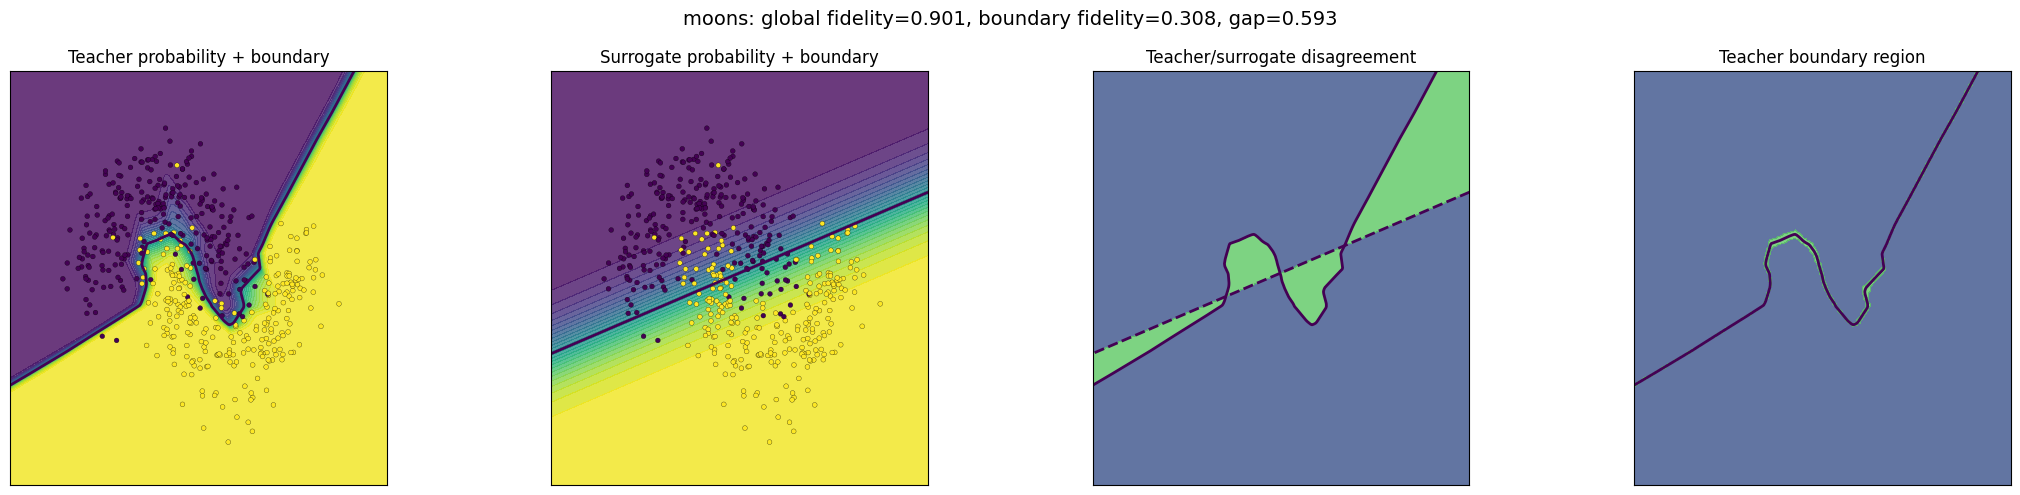

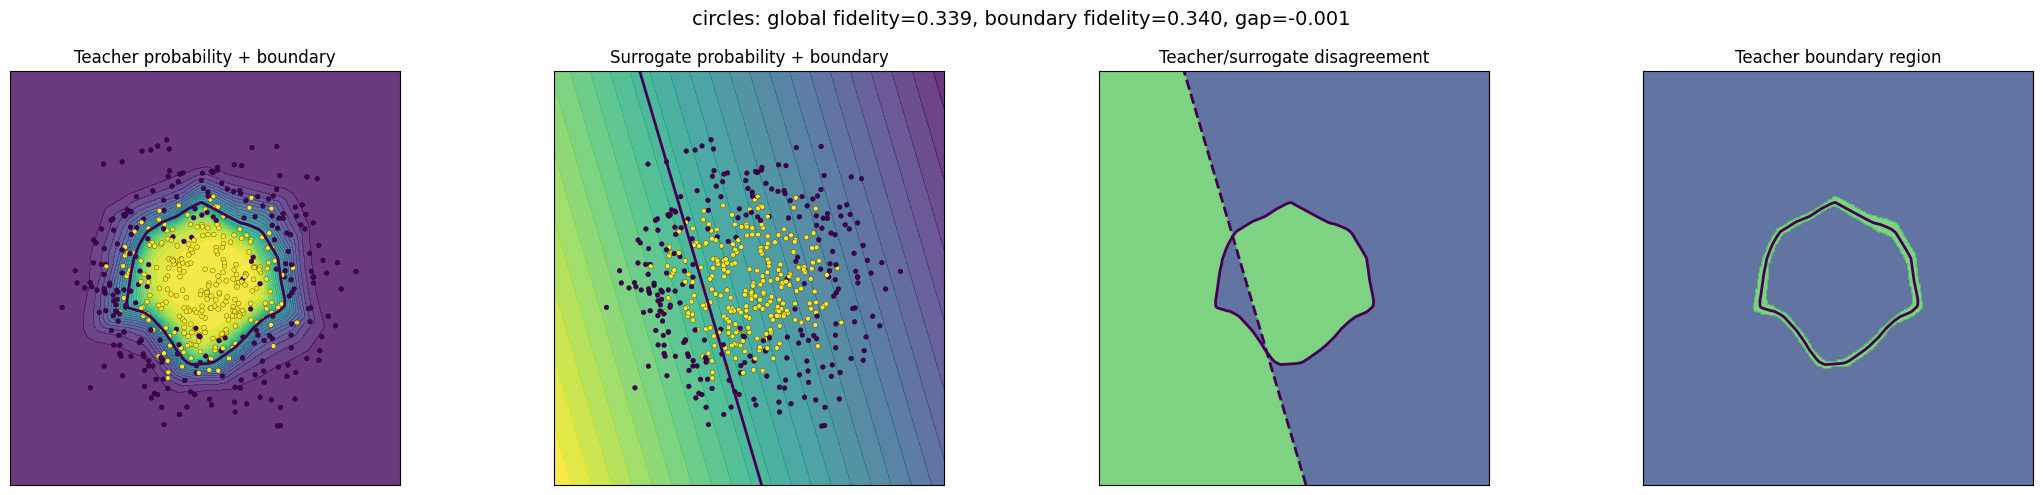

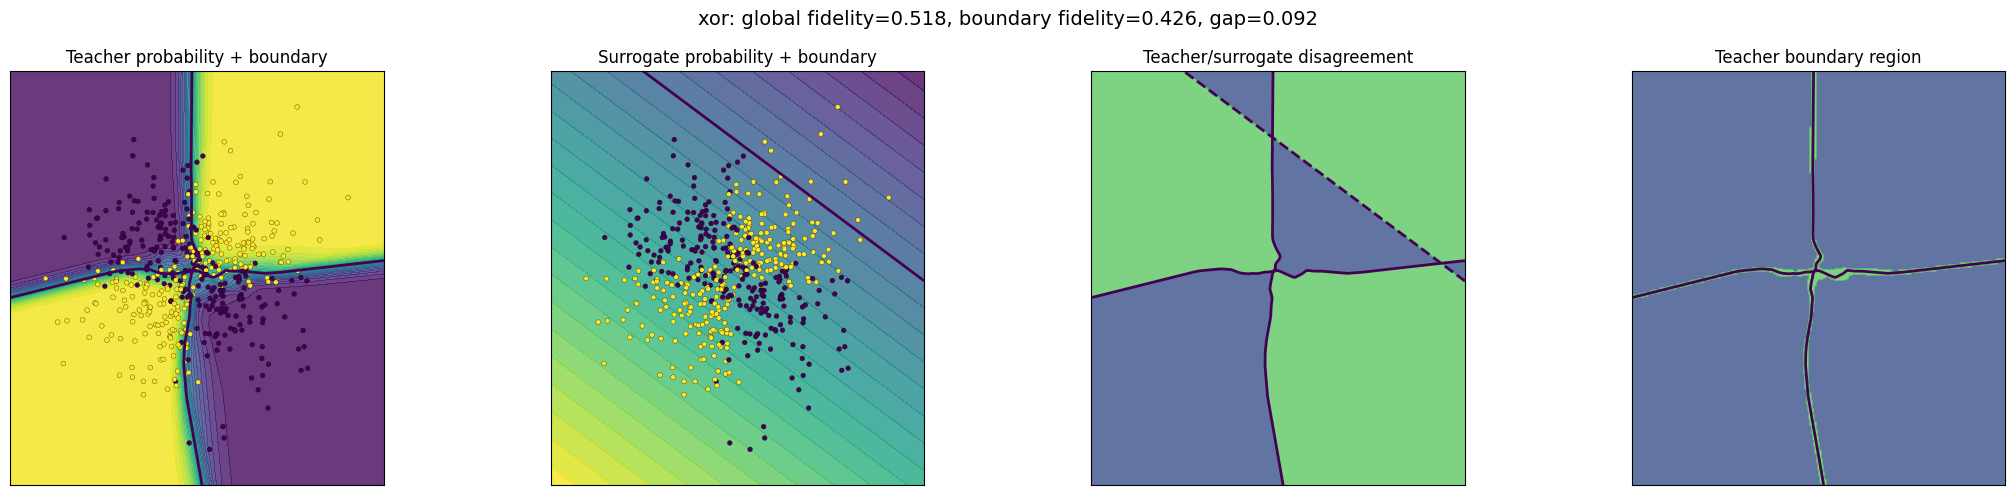

In [10]:
for result in results:
    plot_result(result)


In [11]:
# Optional threshold sensitivity check.
threshold_rows = []
for result in results:
    dataset = result["dataset"]
    teacher_test_p = teacher_probs(result["teacher"], result["X_test"])
    surrogate_test_p = result["surrogate"].predict_proba(result["X_test"])[:, 1]
    for eps in [0.05, 0.10, 0.15, 0.20]:
        row = compute_metrics(result["y_test"], teacher_test_p, surrogate_test_p, eps=eps)
        row["dataset"] = dataset
        row["eps"] = eps
        threshold_rows.append(row)

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary[
    [
        "dataset",
        "eps",
        "global_fidelity",
        "boundary_fidelity",
        "nonboundary_fidelity",
        "boundary_gap",
        "boundary_fraction",
    ]
]

,dataset,eps,global_fidelity,boundary_fidelity,nonboundary_fidelity,boundary_gap,boundary_fraction
0,moons,0.05,0.900952,0.250000,0.911025,0.650952,0.015238
1,moons,0.10,0.900952,0.307692,0.916016,0.593260,0.024762
2,moons,0.15,0.900952,0.444444,0.917160,0.456508,0.034286
3,moons,0.20,0.900952,0.520000,0.920000,0.380952,0.047619
4,circles,0.05,0.339048,0.391304,0.336653,-0.052257,0.043810
5,circles,0.10,0.339048,0.340426,0.338912,-0.001378,0.089524
6,circles,0.15,0.339048,0.391892,0.330377,-0.052844,0.140952
7,circles,0.20,0.339048,0.352941,0.335697,-0.013894,0.194286
8,xor,0.05,0.518095,0.551724,0.516129,-0.033629,0.055238
9,xor,0.10,0.518095,0.425926,0.528662,0.092169,0.102857
